<h2>BodyFat Prediction Using Custom Gradient Descent Multiple Linear Regression On Bodyparts Measurements</h2>

In [33]:
import pandas as pd 
import matplotlib.pyplot as plt 
import math
from pathlib import Path

<h3>Lets get our dataset</h3>

In [34]:
dataset_path = Path("../dataset/bodyfat.csv")
insurance_df = pd.read_csv(dataset_path)
insurance_df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


<h3>Metadata</h3>
The variables listed above, from left to right, are:
<ol>
    <li>Density determined from underwater weighing</li>
    <li>Percent body fat from Siri's (1956) equation  <b> -> Our target variable</b></li> 
    <li>Age (years)</li>
    <li>Weight (lbs)</li>
    <li>Height (inches)</li>
    <li>Neck circumference (cm)</li>
    <li>Chest circumference (cm)</li>
    <li>Abdomen 2 circumference (cm)</li>
    <li>Hip circumference (cm)</li>
    <li>Thigh circumference (cm)</li>
    <li>Knee circumference (cm)</li>
    <li>Ankle circumference (cm)</li>
    <li>Biceps (extended) circumference (cm)</li>
    <li>Forearm circumference (cm)</li>
    <li>Wrist circumference (cm)</li>
</ol>
<i>(Measurement standards are apparently those listed in Benhke and Wilmore (1974), pp. 45-48 where, for instance, the abdomen 2 circumference is measured "laterally, at the level of the iliac crests, and anteriorly, at the umbilicus".)</i>

<i>These data are used to produce the predictive equations for lean body weight given in the abstract "Generalized body composition prediction equation for men using simple measurement techniques", K.W. Penrose, A.G. Nelson, A.G. Fisher, FACSM, Human Performance Research Center, Brigham Young University, Provo, Utah 84602 as listed in Medicine and Science in Sports and Exercise, vol. 17, no. 2, April 1985, p. 189.</i>

<h3>Initial Data Analysis</h3>

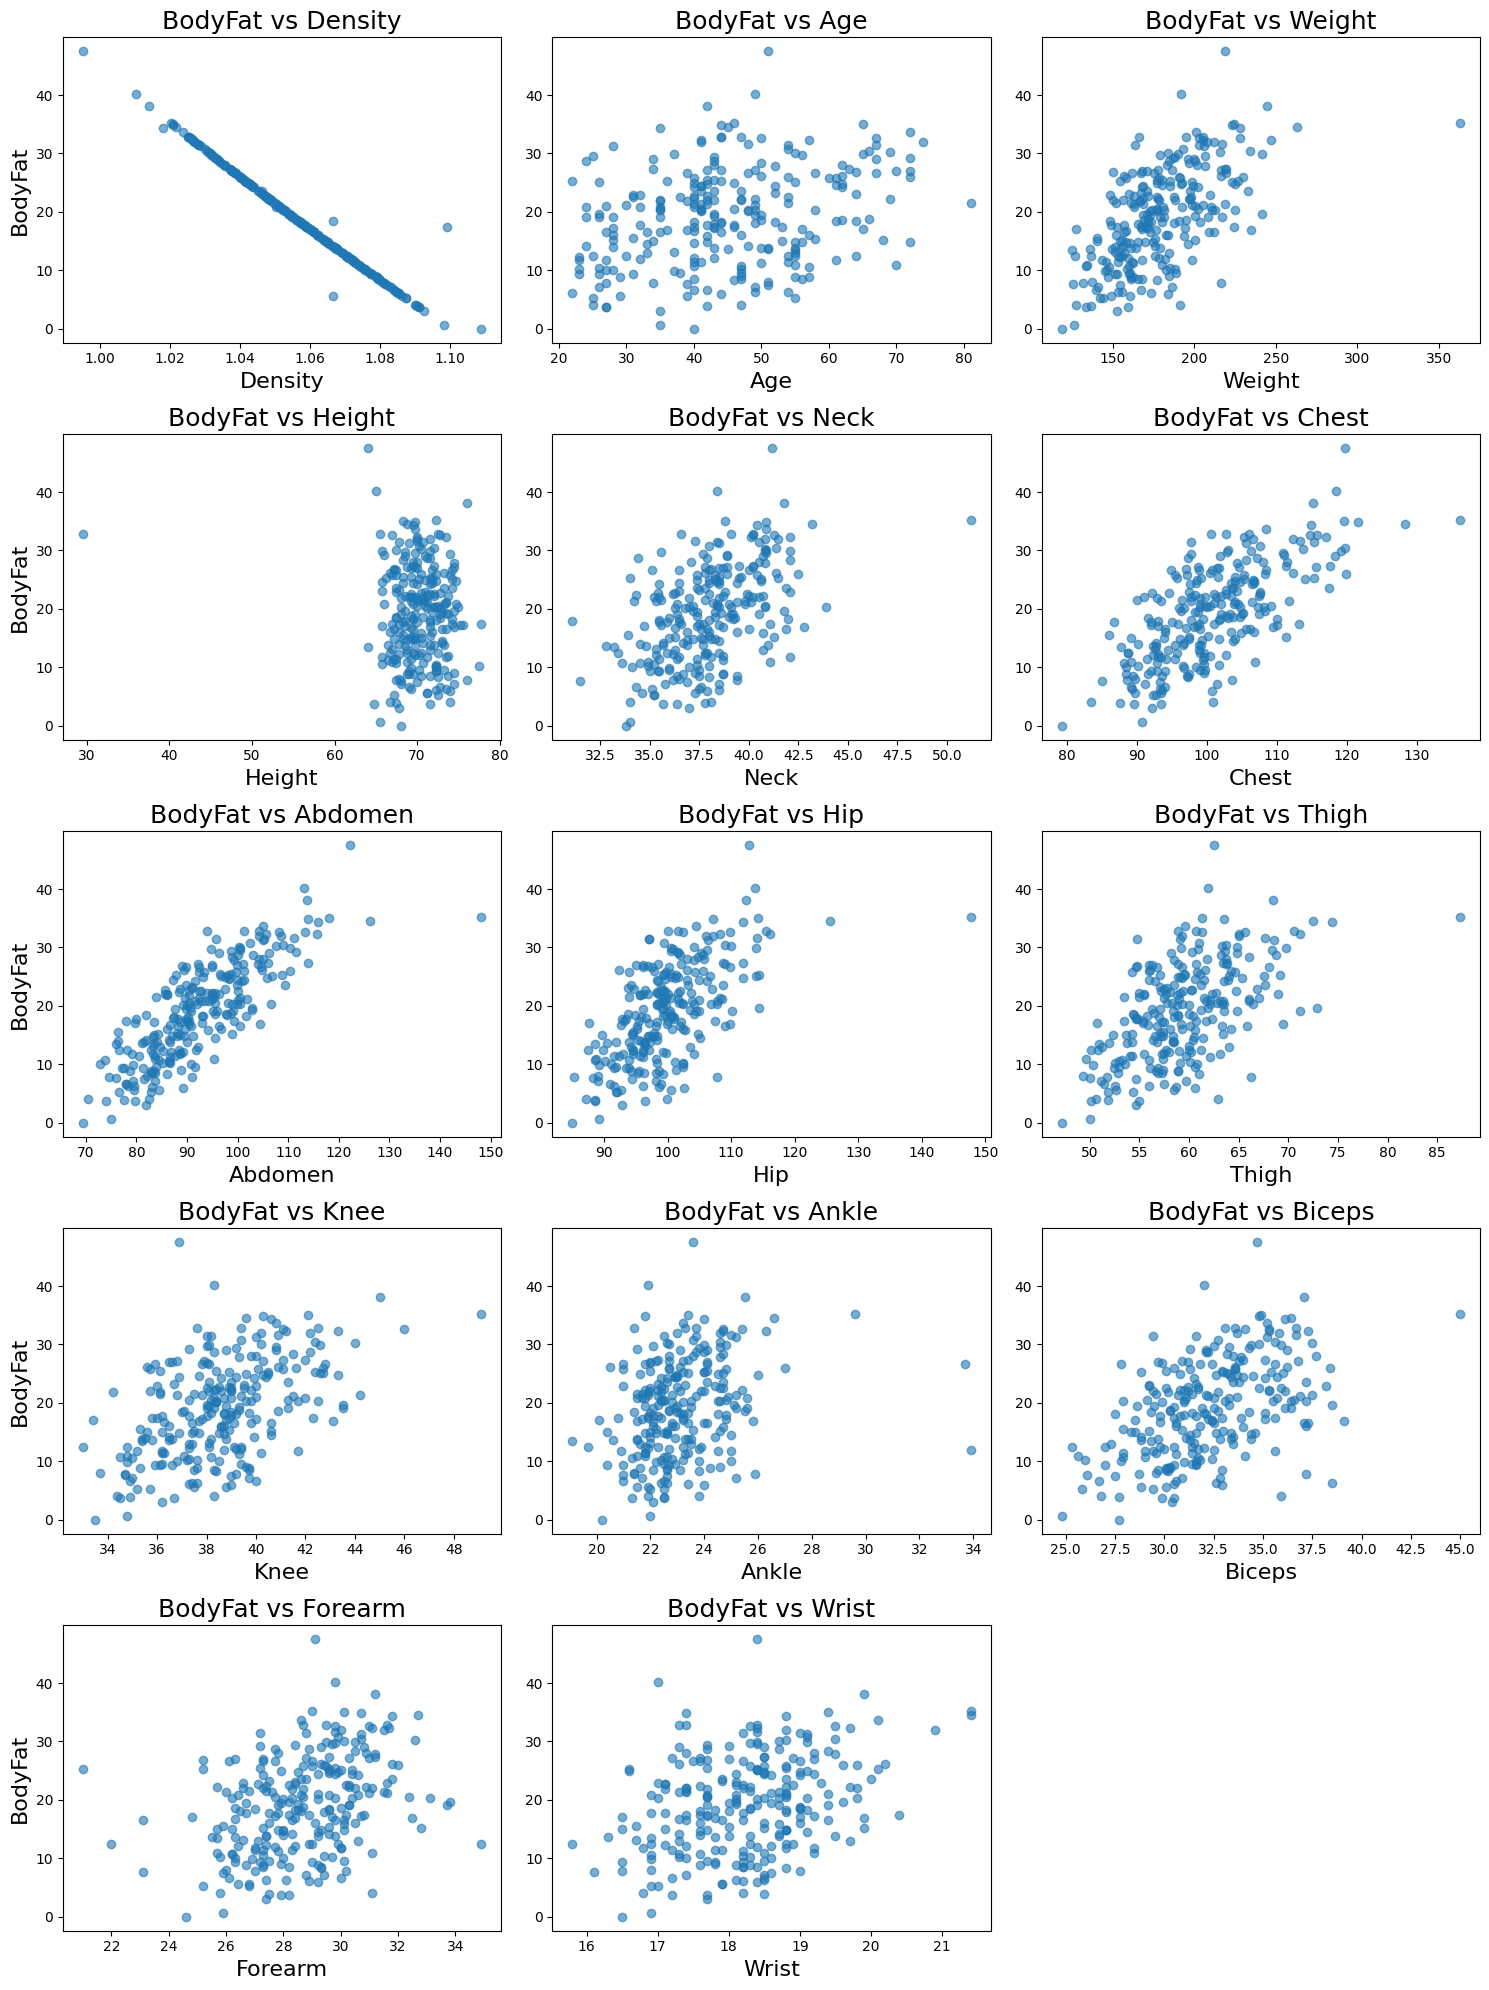

In [35]:
x_train = insurance_df.drop(columns = "BodyFat", inplace= False)
y_train = insurance_df["BodyFat"]
m, n = x_train.shape
headers = x_train.columns.to_list()
n_cols = 3
m_rows = math.ceil(n / n_cols)
fig, ax = plt.subplots(m_rows, n_cols, figsize = (n_cols * 5, m_rows * 4))
ax = ax.flatten()
for i in range(n):
    ax[i].scatter(x_train[headers[i]], y_train, alpha = 0.6)
    ax[i].set_xlabel(headers[i], fontsize = 16)
    ax[i].set_title(f"BodyFat vs {headers[i]}", fontsize = 18)
    if (i % 3 == 0): 
        ax[i].set_ylabel("BodyFat", fontsize = 16)
for j in range(n, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()

We can see that almost all features (except Density) have positive linear relationship compared to bodyfat. The Height vs Bodyfat even though quite dense together because there seem to be an outlier person whose height is around 30 inches (76,2cm) which stretch the graph out. <br>
<b>However</b> the bodyfat vs density graph form an almost perfect straight line, this is because the bodyfat in this dataset is directly computed using density. This means that if we try to run gradient descent on this dataset, then it would completely ignore the other features and would make their weights a very small number. Thus because we would want to predict bodyfat using the other measurements and not just from density, therefore we would want to drop the density column.

In [36]:
x_train.drop(columns= "Density", inplace = True)
x_train.head()

,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


<h3>Feature Scaling</h3>

Next lets handle the data from other features as we can see the data range varies a lot from each features. We will use <b>Z-score normalization</b> for this dataset

In [37]:
from sklearn import preprocessing 

scaler = preprocessing.StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
y_train = y_train.to_numpy().reshape(-1, 1)